# Split inspection

- Paired pre/post images at the same coord (paper §3.2) => label inversion with near-identical backgrounds.
- Random image-level split instead of coord-level (paper §3.5) => cross-split leakage.
- Spatial duplicates across captures (paper §3.3) => inflated metrics.

In [89]:
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
import math, re, hashlib, random
import matplotlib.pyplot as plt
from PIL import Image

# Config
DATA_ROOT = Path("data")
ROUNDINGS = [6, 5, 4, 3]  # coord rounding for overlap checks
MERGE_DISTANCE_M = 50.0   # cross-split neighbor distance (meters)
RANDOM_SEED = 42

assert DATA_ROOT.exists(), f"Missing dataset root: {DATA_ROOT}"
random.seed(RANDOM_SEED)

In [90]:
def iter_images(root: Path):
    for split in sorted(p.name for p in root.iterdir() if p.is_dir()):
        for label_dir in sorted((root / split).iterdir()):
            if not label_dir.is_dir():
                continue
            label = label_dir.name
            for img in label_dir.iterdir():
                if img.suffix.lower() not in {".jpeg", ".jpg", ".png"}:
                    continue
                yield split, label, img

def coord_from_stem(stem: str):
    m = re.match(r"^([-0-9\.]+)_([-0-9\.]+)", stem)
    if not m:
        return None, None
    return float(m.group(1)), float(m.group(2))

def coord_key(lon, lat, rounding):
    return round(lon, rounding), round(lat, rounding)

def haversine_m(lon1, lat1, lon2, lat2):
    R = 6_371_000.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = phi2 - phi1
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))

# Build indexes
images = []
split_counts = Counter()
label_counts = defaultdict(Counter)
split_stems = defaultdict(list)
coord_map = defaultdict(list)  # coord -> list of (split,label,path)

for split, label, img in iter_images(DATA_ROOT):
    stem = img.stem
    lon, lat = coord_from_stem(stem)
    images.append({"split": split, "label": label, "path": img, "stem": stem, "lon": lon, "lat": lat})
    split_counts[split] += 1
    label_counts[split][label] += 1
    split_stems[split].append(stem)
    if lon is not None:
        coord_map[(lon, lat)].append((split, label, img))

print(f"Total images: {len(images)}")

Total images: 23000


## Split / label / stem counts

In [91]:
for split in split_counts:
    stems = Counter(split_stems[split])
    dup_count = sum(1 for v in stems.values() if v > 1)
    print(f"{split}: files={split_counts[split]} unique_stems={len(stems)} duplicate_stems={dup_count} labels={dict(label_counts[split])}")

test: files=2000 unique_stems=1918 duplicate_stems=82 labels={'damage': 1000, 'no_damage': 1000}
train: files=19000 unique_stems=13600 duplicate_stems=5400 labels={'damage': 13000, 'no_damage': 6000}
validation: files=2000 unique_stems=1930 duplicate_stems=70 labels={'damage': 1000, 'no_damage': 1000}


## Images per coordinate (redundancy)

Unique coords: 14223
Mean imgs/coord: 1.62 | max: 4


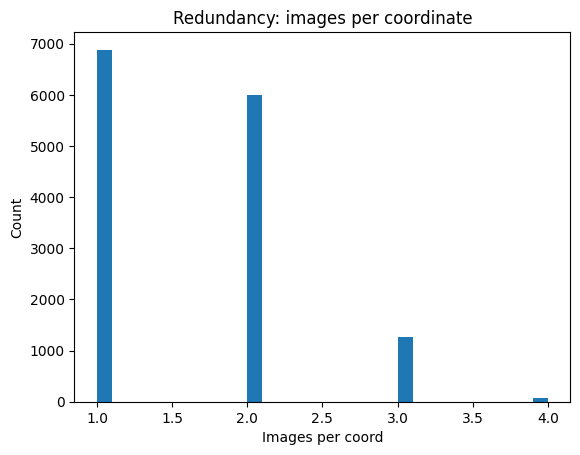

In [92]:
imgs_per_coord = [len(v) for v in coord_map.values()]
print(f"Unique coords: {len(coord_map)}")
print(f"Mean imgs/coord: {sum(imgs_per_coord)/len(imgs_per_coord):.2f} | max: {max(imgs_per_coord)}")
plt.hist(imgs_per_coord, bins=30)
plt.xlabel("Images per coord")
plt.ylabel("Count")
plt.title("Redundancy: images per coordinate")
plt.show()

## Coord-level label/split multiplicity (paper §3.2 & §3.5 risks)

In [93]:
coord_summaries = []
for coord, items in coord_map.items():
    splits = {s for s, _, _ in items}
    labels = {l for _, l, _ in items}
    coord_summaries.append({"coord": coord, "splits": splits, "labels": labels, "count": len(items)})

multi_split = [c for c in coord_summaries if len(c["splits"]) > 1]
conflicting_labels = [c for c in coord_summaries if len(c["labels"]) > 1]
both = [c for c in coord_summaries if len(c["splits"]) > 1 and len(c["labels"]) > 1]

print(f"Coords in >1 split: {len(multi_split)}")
print(f"Coords with both labels (damage/no_damage): {len(conflicting_labels)}")
print(f"Coords with both labels AND multi-split: {len(both)}")

print("\nSample coords with both labels (any split):")
for c in conflicting_labels[:5]:
    print(c["coord"], "splits", c["splits"], "labels", c["labels"], "count", c["count"])

Coords in >1 split: 2972
Coords with both labels (damage/no_damage): 6834
Coords with both labels AND multi-split: 2464

Sample coords with both labels (any split):
(-95.157054, 29.75576) splits {'test', 'train'} labels {'damage', 'no_damage'} count 3
(-95.633563, 29.854204) splits {'test', 'validation', 'train'} labels {'damage', 'no_damage'} count 3
(-95.273016, 29.605567999999998) splits {'test', 'validation', 'train'} labels {'damage', 'no_damage'} count 3
(-95.631002, 29.851936) splits {'test', 'validation', 'train'} labels {'damage', 'no_damage'} count 3
(-95.637663, 29.838739) splits {'test', 'validation', 'train'} labels {'damage', 'no_damage'} count 3


## Cross-split overlaps by rounded coordinate

In [94]:
for r in ROUNDINGS:
    buckets = defaultdict(set)
    for img in images:
        lon, lat = img["lon"], img["lat"]
        if lon is None:
            continue
        buckets[coord_key(lon, lat, r)].add(img["split"])
    overlaps = sum(1 for v in buckets.values() if len(v) > 1)
    print(f"round={r}: coord_groups={len(buckets)} cross-split coords={overlaps}")

round=6: coord_groups=14223 cross-split coords=2972
round=5: coord_groups=14210 cross-split coords=2974
round=4: coord_groups=13813 cross-split coords=2976
round=3: coord_groups=5112 cross-split coords=1989


## Cross-split neighbors within a distance (spatial leakage)

In [95]:
cell_size = MERGE_DISTANCE_M / 111_320.0
grid = defaultdict(list)
coords = []
for img in images:
    lon, lat = img["lon"], img["lat"]
    if lon is None:
        continue
    coords.append(img)
    cell = (int(lon / cell_size), int(lat / cell_size))
    grid[cell].append(len(coords) - 1)

pairs_within = []
pair_counts = defaultdict(int)
unique_coord_pairs = set()
for idx, img in enumerate(coords):
    lon, lat = img["lon"], img["lat"]
    cell = (int(lon / cell_size), int(lat / cell_size))
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for j in grid.get((cell[0] + dx, cell[1] + dy), []):
                if j <= idx:
                    continue
                other = coords[j]
                if img["split"] == other["split"]:
                    continue
                d = haversine_m(lon, lat, other["lon"], other["lat"])
                if d <= MERGE_DISTANCE_M:
                    pairs_within.append((img, other, d))
                    key = tuple(sorted([(round(lon, 6), round(lat, 6)), (round(other["lon"], 6), round(other["lat"], 6))]))
                    unique_coord_pairs.add(key)
                    split_pair = tuple(sorted([img["split"], other["split"]]))
                    pair_counts[split_pair] += 1

print(f"Cross-split image pairs within {MERGE_DISTANCE_M} m: {len(pairs_within)}")
print(f"Unique coord pairs within {MERGE_DISTANCE_M} m: {len(unique_coord_pairs)}")
print("By split pair:")
for k, v in sorted(pair_counts.items()):
    print(f"  {k}: {v}")
for a, b, d in pairs_within[:5]:
    print("-", (a["split"], a["label"], a["path"].name), "<->", (b["split"], b["label"], b["path"].name), f"| {d:.2f} m")

Cross-split image pairs within 50.0 m: 32078
Unique coord pairs within 50.0 m: 14851
By split pair:
  ('test', 'train'): 16218
  ('test', 'validation'): 1789
  ('train', 'validation'): 14071
- ('test', 'damage', '-95.157054_29.75576.jpeg') <-> ('train', 'damage', '-95.15728299999999_29.755621.jpeg') | 26.97 m
- ('test', 'damage', '-95.157054_29.75576.jpeg') <-> ('train', 'damage', '-95.15740500000001_29.755618.jpeg') | 37.38 m
- ('test', 'damage', '-95.157054_29.75576.jpeg') <-> ('train', 'no_damage', '-95.15740500000001_29.755618.jpeg') | 37.38 m
- ('test', 'damage', '-95.157054_29.75576.jpeg') <-> ('train', 'damage', '-95.157294_29.755764000000003.jpeg') | 23.17 m
- ('test', 'damage', '-95.157054_29.75576.jpeg') <-> ('train', 'no_damage', '-95.157294_29.755764000000003.jpeg') | 23.17 m


## Conflicting labels within the same split (temporal pairs kept together)

In [96]:
conflicts_by_split = {}
for split in split_counts:
    coord_labels = defaultdict(set)
    for img in images:
        if img["split"] != split:
            continue
        lon, lat = img["lon"], img["lat"]
        if lon is None:
            continue
        coord_labels[coord_key(lon, lat, ROUNDINGS[0])].add(img["label"])
    conflicts = {k: v for k, v in coord_labels.items() if len(v) > 1}
    conflicts_by_split[split] = conflicts
    print(f"{split}: coords with conflicting labels={len(conflicts)}")

test: coords with conflicting labels=82
train: coords with conflicting labels=5400
validation: coords with conflicting labels=70


## Byte-identical duplicates

In [97]:
hash_map = defaultdict(list)
for img in images:
    h = hashlib.md5(img["path"].read_bytes()).hexdigest()
    hash_map[h].append(img)
dups = {h: v for h, v in hash_map.items() if len(v) > 1}
print(f"Byte-identical duplicate groups: {len(dups)}")
for h, items in list(dups.items())[:5]:
    print(f"\nHash {h} count={len(items)}")
    for img in items:
        print(f"  {img['split']:10s} {img['label']:10s} {img['path'].name}")

Byte-identical duplicate groups: 7

Hash 9ad59bda44e8006e81c91b0f1042058f count=2
  train      damage     -95.269851_29.604838.jpeg
  train      damage     -95.269851_29.604840000000003.jpeg

Hash 846752fb1c9c26f8af5efdf7ed3a709b count=2
  train      damage     -95.272074_29.604429.jpeg
  train      damage     -95.272077_29.604427.jpeg

Hash 0269236c630b26698497381963660cbc count=2
  train      damage     -93.792569_30.226645.jpeg
  train      damage     -93.79257_30.226646000000002.jpeg

Hash 3c4b370c87bac346c416aea54cd5b023 count=2
  train      damage     -93.792377_30.2266.jpeg
  train      damage     -93.792375_30.226599.jpeg

Hash 799cb0a678ea659fe21734251af46356 count=2
  train      no_damage  -95.269851_29.604838.jpeg
  train      no_damage  -95.269851_29.604840000000003.jpeg


## Visual samples

Examples to illustrate redundancy/leakage risks:

Duplicate stem pairs: 5552
Conflicting-label pairs (same coord, same split): 60
Cross-split same-coord pairs: 2972


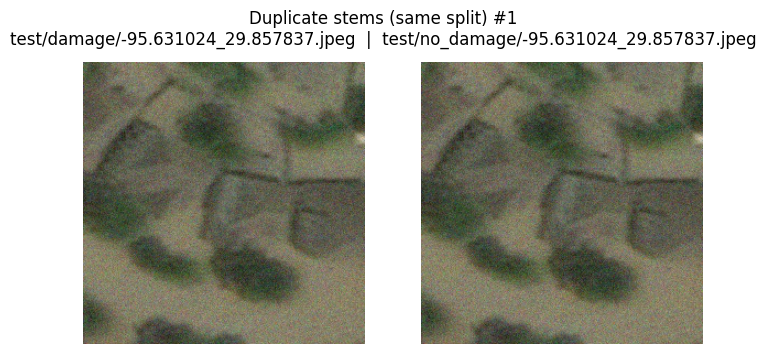

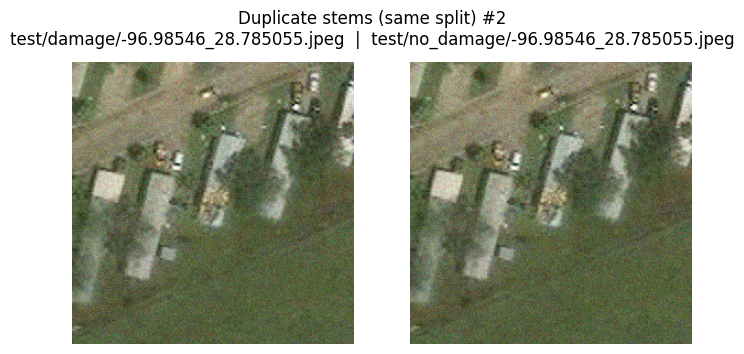

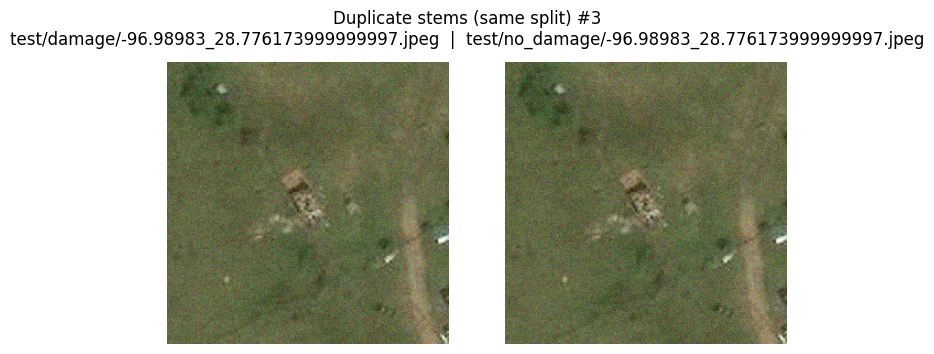

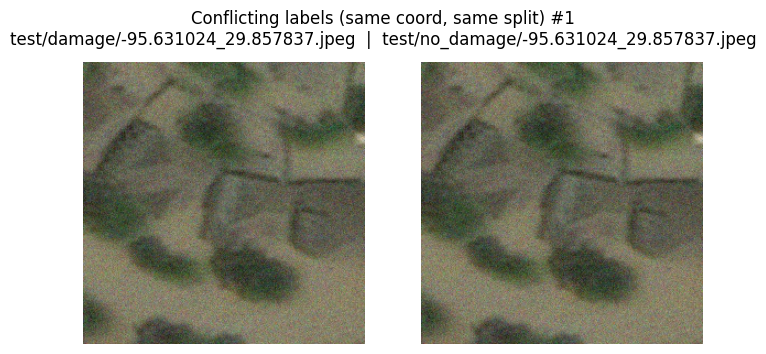

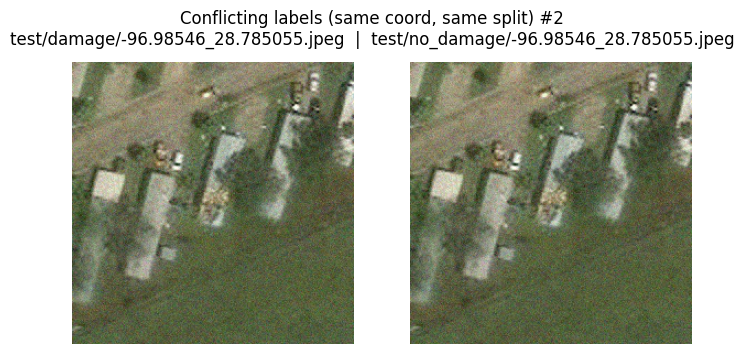

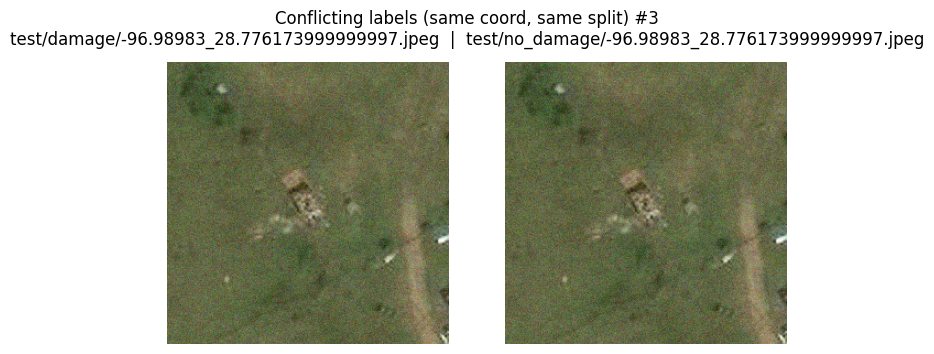

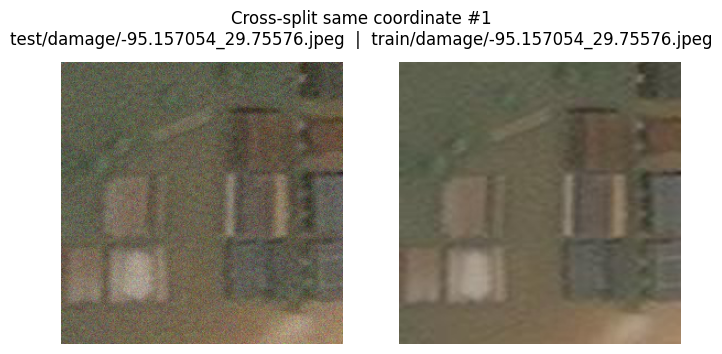

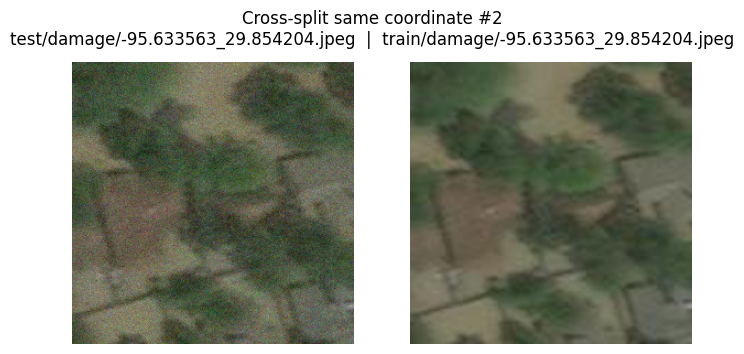

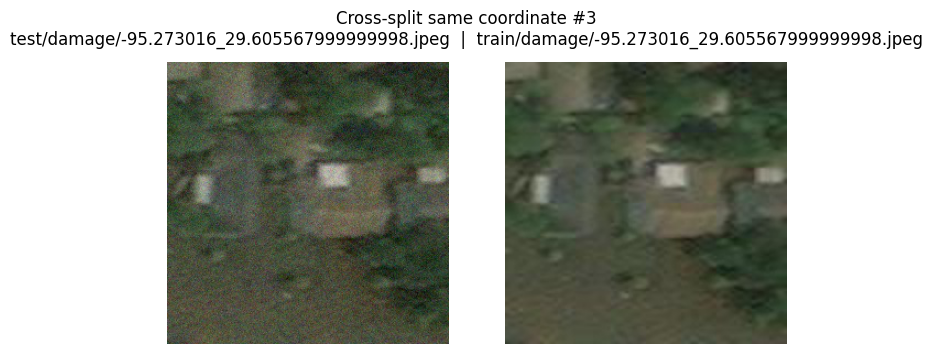

In [98]:
def show_pairs(pairs, title, max_pairs=3):
    pairs = pairs[:max_pairs]
    if not pairs:
        print(f"No pairs to show for: {title}")
        return
    for idx, pair in enumerate(pairs, 1):
        (s1, l1, p1), (s2, l2, p2) = pair
        img1 = next(img for img in images if img["split"] == s1 and img["path"].name == p1)
        img2 = next(img for img in images if img["split"] == s2 and img["path"].name == p2)
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        fig.suptitle(f"{title} #{idx}\n{s1}/{l1}/{p1}  |  {s2}/{l2}/{p2}")
        axes[0].imshow(Image.open(img1["path"]))
        axes[0].axis("off")
        axes[1].imshow(Image.open(img2["path"]))
        axes[1].axis("off")
        plt.show()

# Duplicate stems within a split
duplicate_stem_pairs = []
for split, stems in split_stems.items():
    c = Counter(stems)
    dups = [s for s, v in c.items() if v > 1]
    for stem in dups:
        imgs = [img for img in images if img["split"] == split and img["stem"] == stem]
        for a, b in combinations(imgs, 2):
            duplicate_stem_pairs.append(((a["split"], a["label"], a["path"].name), (b["split"], b["label"], b["path"].name)))

# Conflicting labels within the same split (same coord)
conflicting_pairs = []
for split, conflicts in conflicts_by_split.items():
    for coord in list(conflicts.keys())[:20]:
        imgs = [img for img in images if img["split"] == split and coord_key(img["lon"], img["lat"], ROUNDINGS[0]) == coord]
        for a, b in combinations(imgs, 2):
            if a["label"] == b["label"]:
                continue
            conflicting_pairs.append(((a["split"], a["label"], a["path"].name), (b["split"], b["label"], b["path"].name)))
            break
# Cross-split same coord (any labels)
cross_split_same_coord = []
for c in coord_summaries:
    if len(c["splits"]) <= 1:
        continue
    imgs = coord_map[c["coord"]]
    for a, b in combinations(imgs, 2):
        if a[0] == b[0]:
            continue
        cross_split_same_coord.append(((a[0], a[1], a[2].name), (b[0], b[1], b[2].name)))
        break

print(f"Duplicate stem pairs: {len(duplicate_stem_pairs)}")
print(f"Conflicting-label pairs (same coord, same split): {len(conflicting_pairs)}")
print(f"Cross-split same-coord pairs: {len(cross_split_same_coord)}")

show_pairs(duplicate_stem_pairs, "Duplicate stems (same split)")
show_pairs(conflicting_pairs, "Conflicting labels (same coord, same split)")
show_pairs(cross_split_same_coord, "Cross-split same coordinate")